## IMPORTING NECESSARY LIBRARIES

In [1]:
# Data manipulation and preprocessing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models (for binary classification)
from sklearn.model_selection import train_test_split

# Classification models (binary classification)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Preprocessing: Scaling and Encoding
from sklearn.preprocessing import StandardScaler, LabelEncoder

from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Hyperparameter tuning and cross-validation
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, ShuffleSplit

# Evaluation metrics for binary classification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_curve, auc, RocCurveDisplay

import joblib

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

## LOADING DATA

In [2]:
try:
    df = pd.read_csv('../data/diabetes.csv')
except FileNotFoundError:
    print("File not found")

In [3]:
from scipy.stats import mstats

# Winsorizing specific features
features_to_winsorize = ['BloodPressure', 'Insulin', 'DiabetesPedigreeFunction']

for feature in features_to_winsorize:
    # Apply Winsorization for the identified features
    df[feature] = mstats.winsorize(df[feature], limits=[0.05, 0.05])
    
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,1.136,33,1


In [4]:
df['HighGlucose'] = (df['Glucose'] > 140).astype(int)
df['Age_BMI'] = df['Age'] * df['BMI']

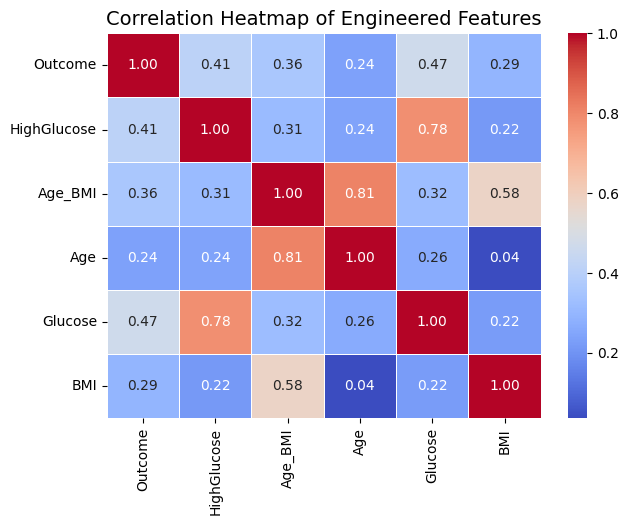

In [5]:
engineered_df = df[['Outcome','HighGlucose', 'Age_BMI','Age', 'Glucose','BMI']]

plt.figure(figsize=(7, 5))
corr = engineered_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Engineered Features', fontsize=14)
plt.show()

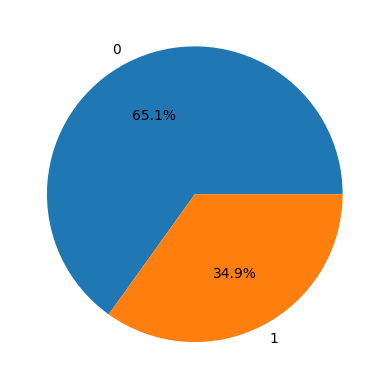

In [6]:
outcome_counts=df["Outcome"].value_counts()
plt.pie(outcome_counts, labels=outcome_counts.index, autopct="%1.1f%%")
plt.show()

## SPLITTING DATA

In [7]:
X = df.drop(columns=['Outcome'])  
y = df['Outcome'] 

In [8]:
df.shape

(768, 11)

## Applying SMOTE to Balance Values

In [9]:
smote = SMOTE(sampling_strategy="auto", random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [10]:
print(y_resampled.value_counts())

Outcome
1    500
0    500
Name: count, dtype: int64


## TRAIN TEST SPLIT

In [11]:
# Split the resampled data into train and test sets
X_train_resample, X_test_resample, y_train_resample, y_test_resample = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=2)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

## MODEL TRAINING

In [13]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=150) ),
    ('SVM', SVC(kernel='rbf', C=1.0, gamma='scale') ),
    ('KNN', KNeighborsClassifier()),
    ('Random Forest Classifier', RandomForestClassifier(random_state=42)),
    ('LightGBM', LGBMClassifier()),  
    ('Naive Bayes', GaussianNB()),   
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('XGBClassifier' ,XGBClassifier())  
]

In [14]:
# Initialize an empty dictionary to store results
model_results_train_test = {}

# Loop over each model for both datasets
for model_name, model in models:  
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics for classification models
    if model_name in ['Logistic Regression', 'SVM', 'KNN', 'Random Forest Classifier', 'LightGBM', 'Naive Bayes', 'Gradient Boosting','XGBClassifier']:
        accuracy_test = accuracy_score(y_test, y_pred_test)
        f1_test = f1_score(y_test, y_pred_test)
        recall_test = recall_score(y_test, y_pred_test)
        cm_test = confusion_matrix(y_test, y_pred_test)
        
        # Store results
        model_results_train_test[model_name] = {
            'Accuracy': accuracy_test,
            'F1 Score': f1_test,
            'Recall': recall_test,
            'Confusion Matrix': cm_test
        }
    

train_test_df = pd.DataFrame(model_results_train_test).T
train_test_df

[LightGBM] [Info] Number of positive: 223, number of negative: 391
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 848
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.363192 -> initscore=-0.561536
[LightGBM] [Info] Start training from score -0.561536
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,Accuracy,F1 Score,Recall,Confusion Matrix
Logistic Regression,0.753247,0.547619,0.511111,"[[93, 16], [22, 23]]"
SVM,0.733766,0.539326,0.533333,"[[89, 20], [21, 24]]"
KNN,0.766234,0.571429,0.533333,"[[94, 15], [21, 24]]"
Random Forest Classifier,0.74026,0.545455,0.533333,"[[90, 19], [21, 24]]"
LightGBM,0.772727,0.615385,0.622222,"[[91, 18], [17, 28]]"
Naive Bayes,0.727273,0.571429,0.622222,"[[84, 25], [17, 28]]"
Gradient Boosting,0.75974,0.602151,0.622222,"[[89, 20], [17, 28]]"
XGBClassifier,0.74026,0.555556,0.555556,"[[89, 20], [20, 25]]"


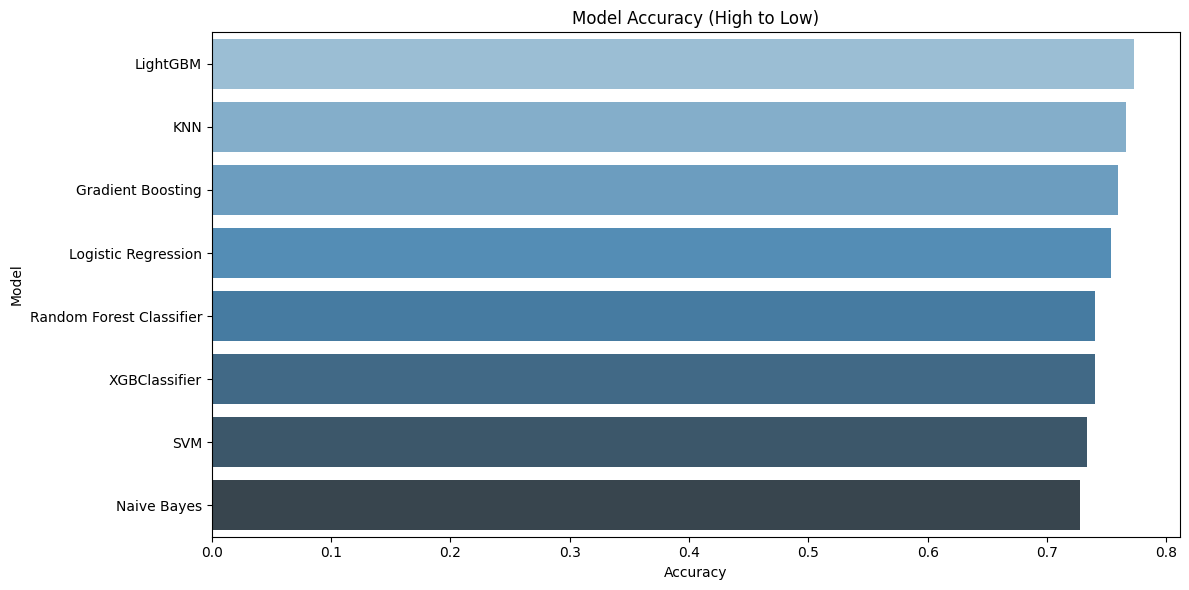

In [15]:
# Sort the DataFrame by Accuracy (descending)
sorted_df = train_test_df.sort_values(by='Accuracy', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y=sorted_df.index, data=sorted_df, palette='Blues_d')
plt.title('Model Accuracy (High to Low)')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

In [16]:
# Initialize an empty dictionary to store results
model_results_train_test_r = {}

# Loop over each model for both datasets
for model_name, model in models:  
    # Train the model
    model.fit(X_train_resample, y_train_resample)
    
    # Make predictions on the test set
    y_pred_test = model.predict(X_test_resample)
    
    # Calculate metrics for classification models
    if model_name in ['Logistic Regression', 'SVM', 'KNN', 'Random Forest Classifier', 'LightGBM', 'Naive Bayes', 'Gradient Boosting','XGBClassifier']:
        accuracy_test = accuracy_score(y_test_resample, y_pred_test)
        f1_test = f1_score(y_test_resample, y_pred_test)
        recall_test = recall_score(y_test_resample, y_pred_test)
        cm_test = confusion_matrix(y_test_resample, y_pred_test)
        
        # Store results
        model_results_train_test_r[model_name] = {
            'Accuracy': accuracy_test,
            'F1 Score': f1_test,
            'Recall': recall_test,
            'Confusion Matrix': cm_test
        }
    

train_test_r_df = pd.DataFrame(model_results_train_test_r).T
train_test_r_df

[LightGBM] [Info] Number of positive: 391, number of negative: 409
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1122
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488750 -> initscore=-0.045008
[LightGBM] [Info] Start training from score -0.045008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

,Accuracy,F1 Score,Recall,Confusion Matrix
Logistic Regression,0.74,0.737374,0.669725,"[[75, 16], [36, 73]]"
SVM,0.71,0.718447,0.678899,"[[68, 23], [35, 74]]"
KNN,0.755,0.76555,0.733945,"[[71, 20], [29, 80]]"
Random Forest Classifier,0.825,0.832536,0.798165,"[[78, 13], [22, 87]]"
LightGBM,0.805,0.816901,0.798165,"[[74, 17], [22, 87]]"
Naive Bayes,0.69,0.670213,0.577982,"[[75, 16], [46, 63]]"
Gradient Boosting,0.78,0.788462,0.752294,"[[74, 17], [27, 82]]"
XGBClassifier,0.825,0.832536,0.798165,"[[78, 13], [22, 87]]"


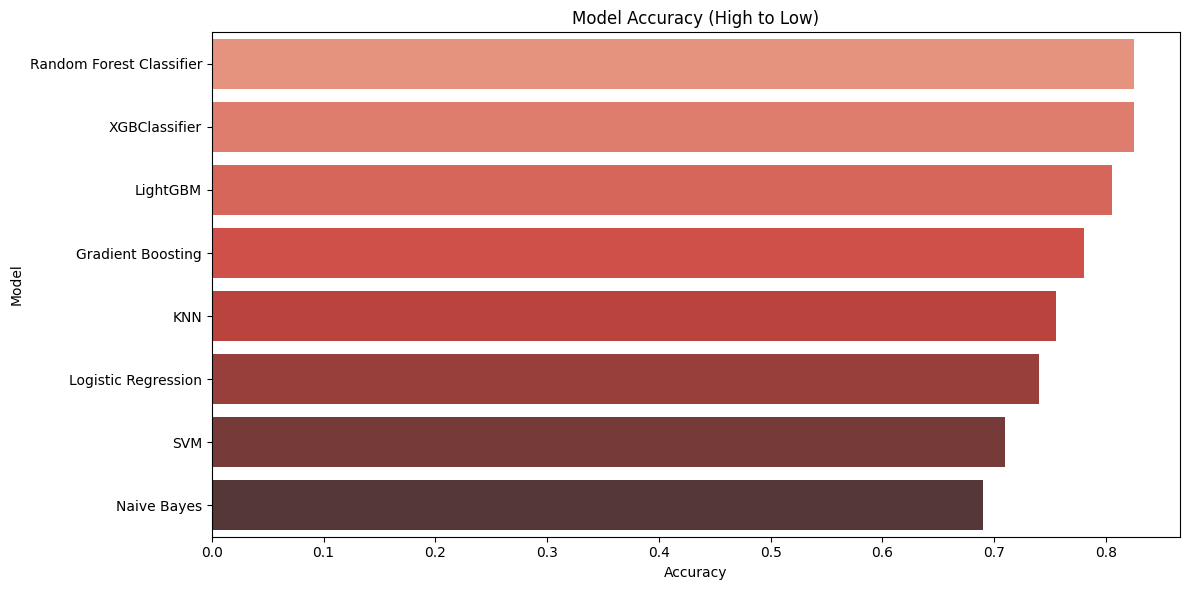

In [17]:
# Sort the DataFrame by Accuracy (descending)
sorted_df = train_test_r_df.sort_values(by='Accuracy', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y=sorted_df.index, data=sorted_df, palette='Reds_d')
plt.title('Model Accuracy (High to Low)')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

## HYPERPARAMETER TUNING

### Random Forest Classifier

In [18]:
params ={'n_estimators': 269, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 6, 'random_state': 42}
rf1 = RandomForestClassifier(**params)

rf1.fit(X_train, y_train)
y_pred = rf1.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred)

print(f"Accuracy on original dataset: {accuracy_rf:.2f}")

Accuracy on original dataset: 0.79


In [19]:
params = {
    'n_estimators': 500,
    'max_depth': 20,
    'min_samples_split': 5,
    'min_samples_leaf': 1,
    'bootstrap': True,                
    'max_features': 'sqrt',          
    'class_weight': 'balanced_subsample',  
    'random_state': 42                
}
rf2 = RandomForestClassifier(**params)

rf2.fit(X_train_resample, y_train_resample)
y_pred_resample_rf = rf2.predict(X_test_resample)
accuracy_rf_resample = accuracy_score(y_test_resample, y_pred_resample_rf)
print(f"Accuracy on resampled dataset: {accuracy_rf_resample:.2f}")

Accuracy on resampled dataset: 0.82


### LightGBM with Hyperparameter Tuning

In [20]:
params = {'num_leaves': 12, 'learning_rate': 0.002, 'n_estimators': 180, 'max_depth': 8, 'random_state': 42}
lgbm1 = LGBMClassifier(**params)

lgbm1.fit(X_train, y_train)
y_pred = lgbm1.predict(X_test)
accuracy_lgbm = accuracy_score(y_test, y_pred)

print(f"Accuracy on original dataest: {accuracy_lgbm:.2f}")

[LightGBM] [Info] Number of positive: 223, number of negative: 391
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 848
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.363192 -> initscore=-0.561536
[LightGBM] [Info] Start training from score -0.561536
Accuracy on original dataest: 0.77


In [21]:
params = {
    'num_leaves': 100,
    'max_depth': 11,
    'learning_rate': 0.18,
    'n_estimators': 70,
    'subsample': 0.9,
    'colsample_bytree': 0.6,
    'min_child_samples': 20,           
    'min_child_weight': 0.001,         
    'reg_alpha': 0.01,                  
    'reg_lambda': 0.02,                 
    'random_state': 42
}

lgbm2 = LGBMClassifier(**params)
lgbm2.fit(X_train_resample, y_train_resample)
y_pred_resample_lgbm = lgbm2.predict(X_test_resample)
accuracy_lgbm_resample = accuracy_score(y_test_resample, y_pred_resample_lgbm)
print(f"Accuracy on resampled dataset (LightGBM): {accuracy_lgbm_resample:.2f}")


[LightGBM] [Info] Number of positive: 391, number of negative: 409
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1122
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488750 -> initscore=-0.045008
[LightGBM] [Info] Start training from score -0.045008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

## XGBoost with Hyperparameter Tuning

In [22]:
params = {'max_depth': 9, 'learning_rate': 0.0016, 'n_estimators': 292, 'gamma': 1.8, 'random_state': 42}
xgb1 = XGBClassifier(**params)

xgb1.fit(X_train, y_train)

y_pred = xgb1.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred)
print(f"Accuracy on original dataset: {accuracy_xgb:.2f}")

Accuracy on original dataset: 0.79


In [23]:
params = {
    'max_depth': 10,
    'learning_rate': 0.06,
    'n_estimators': 397,
    'gamma': 0.8,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scale_pos_weight': 1,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42
}

xgb2 = XGBClassifier(**params)
xgb2.fit(X_train_resample, y_train_resample)

y_pred_resample_xgb = xgb2.predict(X_test_resample)
accuracy_resample_xgb = accuracy_score(y_test_resample, y_pred_resample_xgb)
print(f"Accuracy on resampled dataset: {accuracy_resample_xgb:.2f}")

Accuracy on resampled dataset: 0.83


## Selecting Best Model

In [24]:
# === Evaluation on Resampled Test Set ===
print("=== RandomForestClassifier Evaluation on Resampled Test Set ===")
y_train_pred_rf = rf2.predict(X_train_resample)
y_test_pred_rf = rf2.predict(X_test_resample)

print("Train Accuracy (Resampled):", accuracy_score(y_train_resample, y_train_pred_rf))
print("Test Accuracy (Resampled):", accuracy_score(y_test_resample, y_test_pred_rf))
print("\nClassification Report (Resampled Test Set):")
print(classification_report(y_test_resample, y_test_pred_rf))
print("Confusion Matrix (Resampled Test Set):")
print(confusion_matrix(y_test_resample, y_test_pred_rf))

# === Evaluation on Original Test Set ===
print("\n=== RandomForestClassifier Evaluation on Original Test Set ===")
y_test_pred_orig = rf2.predict(X_test)
print("Accuracy (Original Test Set):", accuracy_score(y_test, y_test_pred_orig))
print("\nClassification Report (Original Test Set):")
print(classification_report(y_test, y_test_pred_orig))
print("Confusion Matrix (Original Test Set):")
print(confusion_matrix(y_test, y_test_pred_orig))

=== RandomForestClassifier Evaluation on Resampled Test Set ===
Train Accuracy (Resampled): 0.995
Test Accuracy (Resampled): 0.82

Classification Report (Resampled Test Set):
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        91
           1       0.86      0.80      0.83       109

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200

Confusion Matrix (Resampled Test Set):
[[77 14]
 [22 87]]

=== RandomForestClassifier Evaluation on Original Test Set ===
Accuracy (Original Test Set): 0.9155844155844156

Classification Report (Original Test Set):
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       109
           1       0.83      0.89      0.86        45

    accuracy                           0.92       154
   macro avg       0.89      0.91      0.90       154
weighted av

In [25]:
# === Evaluation on Resampled Test Set ===
print("=== XGBClassifier (xgb2) Evaluation on Resampled Test Set ===")
y_train_pred_xgb = xgb2.predict(X_train_resample)
y_test_pred_xgb = xgb2.predict(X_test_resample)

print("Train Accuracy (Resampled):", accuracy_score(y_train_resample, y_train_pred_xgb))
print("Test Accuracy (Resampled):", accuracy_score(y_test_resample, y_test_pred_xgb))
print("\nClassification Report (Resampled Test Set):")
print(classification_report(y_test_resample, y_test_pred_xgb))
print("Confusion Matrix (Resampled Test Set):")
print(confusion_matrix(y_test_resample, y_test_pred_xgb))

# === Evaluation on Original Test Set ===
print("\n=== XGBClassifier (xgb2) Evaluation on Original Test Set ===")
y_test_pred_orig_xgb = xgb2.predict(X_test)
print("Accuracy (Original Test Set):", accuracy_score(y_test, y_test_pred_orig_xgb))
print("\nClassification Report (Original Test Set):")
print(classification_report(y_test, y_test_pred_orig_xgb))
print("Confusion Matrix (Original Test Set):")
print(confusion_matrix(y_test, y_test_pred_orig_xgb))

=== XGBClassifier (xgb2) Evaluation on Resampled Test Set ===
Train Accuracy (Resampled): 0.985
Test Accuracy (Resampled): 0.83

Classification Report (Resampled Test Set):
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        91
           1       0.86      0.83      0.84       109

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200

Confusion Matrix (Resampled Test Set):
[[76 15]
 [19 90]]

=== XGBClassifier (xgb2) Evaluation on Original Test Set ===
Accuracy (Original Test Set): 0.922077922077922

Classification Report (Original Test Set):
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       109
           1       0.85      0.89      0.87        45

    accuracy                           0.92       154
   macro avg       0.90      0.91      0.91       154
weighted avg    

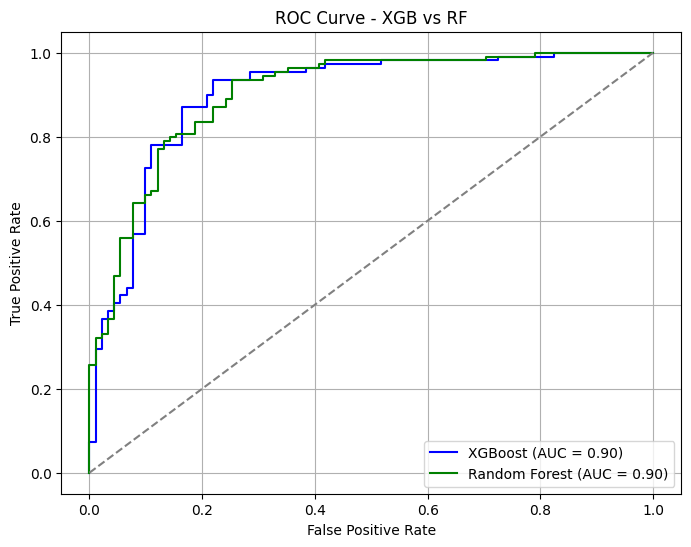

In [26]:
# ROC Curve
y_proba_xgb = xgb2.predict_proba(X_test_resample)[:, 1]
y_proba_rf = rf2.predict_proba(X_test_resample)[:, 1]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_resample, y_proba_xgb)
fpr_rf, tpr_rf, _ = roc_curve(y_test_resample, y_proba_rf)

roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGB vs RF')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

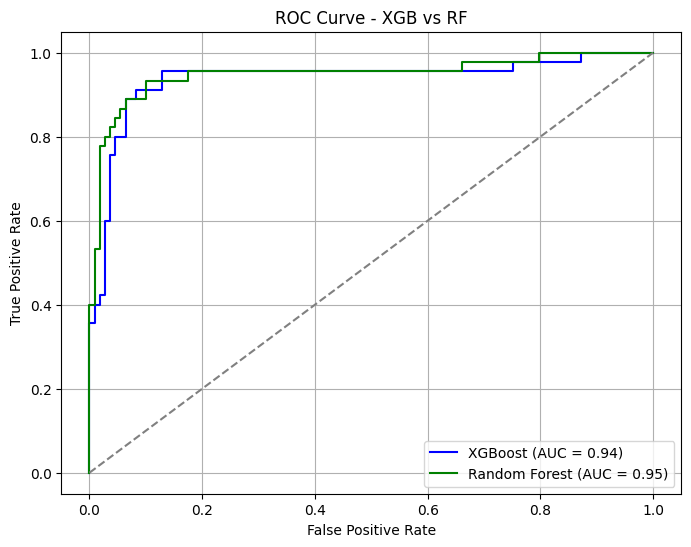

In [27]:
# ROC Curve
y_proba_xgb = xgb2.predict_proba(X_test)[:, 1]
y_proba_rf = rf2.predict_proba(X_test)[:, 1]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGB vs RF')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()